In [1]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
import os, re, csv, glob, random, time, warnings
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

warnings.filterwarnings('ignore')
print('PyTorch :', torch.__version__)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device  :', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU     :', torch.cuda.get_device_name(0))

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4


In [3]:
IMAGES_ROOT      = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset'
ANNOTATIONS_ROOT = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations'

MAX_VIDEOS   = 200
SAMPLE_EVERY = 3     
SEQ_LEN      = 5


FEAT_DIM    = 1280
HIDDEN_DIM  = 256
NUM_LAYERS  = 2
DROPOUT     = 0.3

BATCH_SIZE   = 64
LR           = 1e-3
EPOCHS       = 8
EARLY_STOP   = 5
LAMBDA_ORD   = 0.5
CLIP_NORM    = 1.0
SEED         = 42
NUM_WORKERS  = 0

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)

for p in [IMAGES_ROOT, ANNOTATIONS_ROOT]:
    ok = os.path.isdir(p)
    print(f'  {"OK" if ok else "MISSING"} : {p}')
    if ok:
        print(f'         ({len(os.listdir(p))} entries)')

  OK : /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset
         (704 entries)
  OK : /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations
         (704 entries)


In [4]:
STAGE_ORDER = [
    'tPB2', 'tPNa', 'tPNf', 't2',
    't3',   't4',   't5',   't6',
    't7',   't8',   't9+',  'tM',
    'tSB',  'tB',   'tEB',  'tHB',
]
STAGE_TO_IDX = {s: i for i, s in enumerate(STAGE_ORDER)}
IDX_TO_STAGE = {i: s for s, i in STAGE_TO_IDX.items()}
NUM_CLASSES  = len(STAGE_ORDER)
print(f'{NUM_CLASSES} classes:', STAGE_ORDER)

16 classes: ['tPB2', 'tPNa', 'tPNf', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tM', 'tSB', 'tB', 'tEB', 'tHB']


In [5]:


def parse_annotation_csv(csv_path):
    frame_label = {}
    try:
        with open(csv_path, newline='', encoding='utf-8-sig') as fh:
            sample = fh.read(2048)
            fh.seek(0)
            if not sample.strip():
                return {}
            has_header = not sample.strip()[0].isdigit()
            reader = csv.reader(fh)
            if has_header:
                header    = [c.strip().lower() for c in next(reader)]
                stage_col = next((i for i,h in enumerate(header)
                                  if 'stage' in h or 'phase' in h), 0)
                start_col = next((i for i,h in enumerate(header)
                                  if 'start' in h), 1)
                end_col   = next((i for i,h in enumerate(header)
                                  if 'end' in h), 2)
            else:
                stage_col, start_col, end_col = 0, 1, 2
            for row in reader:
                if len(row) < 3:
                    continue
                try:
                    stage = row[stage_col].strip()
                    start = int(float(row[start_col].strip()))
                    end   = int(float(row[end_col].strip()))
                except (ValueError, IndexError):
                    continue
                if stage not in STAGE_TO_IDX:
                    continue
                cls = STAGE_TO_IDX[stage]
                for f in range(start, end + 1):
                    frame_label[f] = cls
    except Exception as e:
        print(f'  [WARN] {csv_path}: {e}')
    return frame_label


def extract_frame_number(filepath):
    stem = os.path.splitext(os.path.basename(filepath))[0]
    nums = re.findall(r'\d+', stem)
    return int(nums[-1]) if nums else None


def find_csv(annotations_root, embryo_id):
    exact = os.path.join(annotations_root, f'{embryo_id}.csv')
    if os.path.isfile(exact):
        return exact
    for f in os.listdir(annotations_root):
        if f.startswith(embryo_id) and f.endswith('.csv'):
            return os.path.join(annotations_root, f)
    low = embryo_id.lower()
    for f in os.listdir(annotations_root):
        if f.lower().startswith(low) and f.lower().endswith('.csv'):
            return os.path.join(annotations_root, f)
    return None

print('Parsers defined.')

Parsers defined.


In [6]:
def build_video_dict(images_root, annotations_root, max_videos, sample_every):
    video_dict = {}
    all_dirs   = sorted(d for d in os.listdir(images_root)
                        if os.path.isdir(os.path.join(images_root, d)))
    selected = all_dirs[:max_videos]
    print(f'Total folders: {len(all_dirs)}  Using: {len(selected)}')

    no_csv = 0
    for embryo_id in selected:
        csv_path = find_csv(annotations_root, embryo_id)
        if csv_path is None:
            no_csv += 1; continue
        frame_label = parse_annotation_csv(csv_path)
        if not frame_label:
            no_csv += 1; continue

        img_files = sorted(
            glob.glob(os.path.join(images_root, embryo_id, '*.jpg'))  +
            glob.glob(os.path.join(images_root, embryo_id, '*.jpeg')) +
            glob.glob(os.path.join(images_root, embryo_id, '*.png'))
        )
        frames = []
        for path in img_files:
            fn = extract_frame_number(path)
            if fn is None or fn not in frame_label:
                continue
            if sample_every > 1 and fn % sample_every != 0:
                continue
            frames.append((fn, path, frame_label[fn]))

        if len(frames) >= SEQ_LEN:
            frames.sort(key=lambda x: x[0])
            video_dict[embryo_id] = frames
        else:
            no_csv += 1

    total_frames = sum(len(v) for v in video_dict.values())
    print(f'Videos skipped: {no_csv}  Videos kept: {len(video_dict)}')
    print(f'Total frames  : {total_frames}')
    if not video_dict:
        raise RuntimeError('video_dict is empty — check paths!')
    return video_dict


video_dict = build_video_dict(IMAGES_ROOT, ANNOTATIONS_ROOT,
                              MAX_VIDEOS, SAMPLE_EVERY)

Total folders: 704  Using: 200
Videos skipped: 0  Videos kept: 200
Total frames  : 27359


In [7]:
def video_wise_split(video_dict, train=0.70, val=0.15, seed=42):
    ids = list(video_dict.keys())
    random.seed(seed); random.shuffle(ids)
    n = len(ids)
    n_tr = int(n * train); n_va = int(n * val)
    tr_ids = ids[:n_tr]
    va_ids = ids[n_tr: n_tr + n_va]
    te_ids = ids[n_tr + n_va:]
    print(f'Train: {len(tr_ids)} videos  Val: {len(va_ids)}  Test: {len(te_ids)}')
    return tr_ids, va_ids, te_ids


train_ids, val_ids, test_ids = video_wise_split(video_dict, seed=SEED)


def build_sequences(video_dict, video_ids, seq_len=SEQ_LEN):
    seqs = []
    for vid in video_ids:
        frames = video_dict[vid]
        for i in range(len(frames) - seq_len + 1):
            window = frames[i: i + seq_len]
            paths  = [w[1] for w in window]
            label  = window[-1][2]            # label of last frame (already int)
            seqs.append((paths, label))
    return seqs


train_seqs = build_sequences(video_dict, train_ids)
val_seqs   = build_sequences(video_dict, val_ids)
test_seqs  = build_sequences(video_dict, test_ids)
print(f'Train seqs: {len(train_seqs)}  Val: {len(val_seqs)}  Test: {len(test_seqs)}')

Train: 140 videos  Val: 30  Test: 30
Train seqs: 19210  Val: 3682  Test: 3667


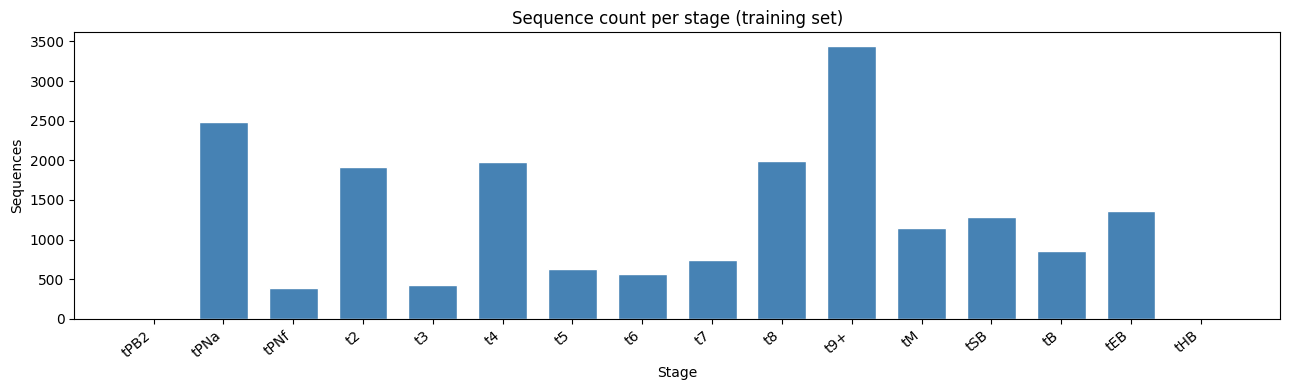

In [8]:
train_labels = [s[1] for s in train_seqs]
counts = Counter(train_labels)
stages = [IDX_TO_STAGE[i] for i in range(NUM_CLASSES)]
cnts   = [counts.get(i, 0) for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(stages, cnts, color='steelblue', edgecolor='white', width=0.7)
ax.set_title('Sequence count per stage (training set)')
ax.set_xlabel('Stage'); ax.set_ylabel('Sequences')
ax.set_xticklabels(stages, rotation=40, ha='right')
plt.tight_layout(); plt.show()

In [9]:
TRAIN_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
VAL_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


class SequenceDataset(Dataset):

    def __init__(self, sequences, transform):
        self.sequences = sequences
        self.transform = transform

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        paths, label = self.sequences[idx]
        imgs = []
        for p in paths:
            try:
                img = Image.open(p).convert('RGB')
                imgs.append(self.transform(img))
            except Exception:
                imgs.append(torch.zeros(3, 224, 224))
        return torch.stack(imgs), label   # (SEQ_LEN, 3, 224, 224)


train_ds = SequenceDataset(train_seqs, TRAIN_TF)
val_ds   = SequenceDataset(val_seqs,   VAL_TF)
test_ds  = SequenceDataset(test_seqs,  VAL_TF)
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

class_w_sampler = {c: 1.0 / max(counts[c], 1) for c in range(NUM_CLASSES)}
sample_weights  = torch.tensor([class_w_sampler[s[1]] for s in train_seqs])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)
print(f'Train batches: {len(train_loader)}')

Train: 19210  Val: 3682  Test: 3667
Train batches: 301


In [10]:
def effective_num_weights(counts_dict, num_classes):
   
    total = sum(counts_dict.values())
    beta  = (total - 1) / total
    w = torch.zeros(num_classes)
    for c in range(num_classes):
        n_c     = max(counts_dict.get(c, 1), 1)
        eff_num = (1.0 - beta ** n_c) / (1.0 - beta)
        w[c]    = 1.0 / eff_num
    return w / w.mean()


class CombinedLoss(nn.Module):

    def __init__(self, class_weights, lambda_ord=LAMBDA_ORD):
        super().__init__()
        self.lambda_ord = lambda_ord
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        ranks = torch.arange(NUM_CLASSES, dtype=torch.float32) / (NUM_CLASSES - 1)
        self.register_buffer('ranks', ranks)

    def forward(self, logits, targets):
        l_wce         = self.ce(logits, targets)
        probs         = F.softmax(logits, dim=1)
        expected_rank = (probs * self.ranks.to(logits.device)).sum(dim=1)
        true_rank     = targets.float() / (NUM_CLASSES - 1)
        l_ord         = F.mse_loss(expected_rank, true_rank)
        return l_wce + self.lambda_ord * l_ord, l_wce, l_ord


eff_w = effective_num_weights(counts, NUM_CLASSES)
print('Class weights (Effective Num Samples):')
for i in range(NUM_CLASSES):
    print(f'  {IDX_TO_STAGE[i]:<8}: {eff_w[i]:.4f}')

Class weights (Effective Num Samples):
  tPB2    : 7.9376
  tPNa    : 0.0034
  tPNf    : 0.0204
  t2      : 0.0044
  t3      : 0.0186
  t4      : 0.0042
  t5      : 0.0129
  t6      : 0.0142
  t7      : 0.0109
  t8      : 0.0042
  t9+     : 0.0025
  tM      : 0.0071
  tSB     : 0.0064
  tB      : 0.0095
  tEB     : 0.0061
  tHB     : 7.9376


In [11]:
class EmbryoCNNLSTM(nn.Module):

    def __init__(self, feat_dim=FEAT_DIM, hidden_dim=HIDDEN_DIM,
                 num_layers=NUM_LAYERS, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()

        backbone = models.mobilenet_v2(
            weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
        )
        self.cnn = nn.Sequential(
            backbone.features,
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        
        for param in self.cnn.parameters():
            param.requires_grad = False
        
        for i in [16, 17, 18]:
            for param in backbone.features[i].parameters():
                param.requires_grad = True

        self.feat_norm  = nn.LayerNorm(feat_dim)
        self.lstm       = nn.LSTM(feat_dim, hidden_dim, num_layers,
                                  batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.shape
        feats = self.cnn(x.view(B*T, C, H, W))    # (B*T, 1280)
        feats = self.feat_norm(feats).view(B, T, -1)  # (B, T, 1280)
        _, (h_n, _) = self.lstm(feats)
        return self.classifier(self.dropout(h_n[-1]))  # (B, num_classes)


model     = EmbryoCNNLSTM().to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}')
print(f'Frozen params    : {total - trainable:,}')

with torch.no_grad():
    dummy = torch.zeros(2, SEQ_LEN, 3, 224, 224).to(DEVICE)
    out   = model(dummy)
print(f'Forward pass OK — output shape: {out.shape}  (expected [2, {NUM_CLASSES}])')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 172MB/s]


Total params     : 4,331,792
Trainable params : 3,314,000
Frozen params    : 1,017,792
Forward pass OK — output shape: torch.Size([2, 16])  (expected [2, 16])


In [12]:
criterion = CombinedLoss(class_weights=eff_w.to(DEVICE), lambda_ord=LAMBDA_ORD)

LR_CNN  = LR * 0.1   # 1e-4
LR_LSTM = LR          # 1e-3

cnn_params  = [p for p in model.cnn.parameters()       if p.requires_grad]
norm_params = list(model.feat_norm.parameters())
lstm_params = list(model.lstm.parameters()) + list(model.classifier.parameters())

optimizer = torch.optim.Adam([
    {'params': cnn_params,  'lr': LR_CNN},
    {'params': norm_params, 'lr': LR_LSTM},
    {'params': lstm_params, 'lr': LR_LSTM},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)
print(f'Optimizer ready — LR_CNN={LR_CNN}  LR_LSTM={LR_LSTM}')

Optimizer ready — LR_CNN=0.0001  LR_LSTM=0.001


In [13]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    tot_loss = tot_wce = tot_ord = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss, l_wce, l_ord = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM)
        optimizer.step()
        n         = labels.size(0)
        tot_loss += loss.item()   * n
        tot_wce  += l_wce.item() * n
        tot_ord  += l_ord.item() * n
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += n
    return {'loss': tot_loss/total, 'wce': tot_wce/total,
            'ord':  tot_ord/total,  'acc': correct/total}


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    tot_loss = tot_wce = correct = total = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss, l_wce, _ = criterion(logits, labels)
        n         = labels.size(0)
        tot_loss += loss.item()   * n
        tot_wce  += l_wce.item() * n
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += n
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return {'loss':   tot_loss / total,
            'wce':    tot_wce  / total,
            'acc':    correct  / total,
            'preds':  all_preds,
            'labels': all_labels}

print('Train/eval functions defined.')

Train/eval functions defined.


In [21]:
hist = {'tr_loss':[], 'tr_wce':[], 'tr_ord':[], 'tr_acc':[],
        'va_loss':[], 'va_wce':[], 'va_acc':[]}

best_val_wce   = float('inf')
best_state     = None
patience_count = 0

print(f'Training | epochs={EPOCHS} | LR_LSTM={LR_LSTM} LR_CNN={LR_CNN} | device={DEVICE}')
print('-' * 80)

for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = train_epoch(model, train_loader, criterion, optimizer)
    va = eval_epoch( model, val_loader,   criterion)

    scheduler.step(va['wce'])  

    hist['tr_loss'].append(tr['loss']); hist['tr_wce'].append(tr['wce'])
    hist['tr_ord'].append(tr['ord']);   hist['tr_acc'].append(tr['acc'])
    hist['va_loss'].append(va['loss']); hist['va_wce'].append(va['wce'])
    hist['va_acc'].append(va['acc'])

    print(f'Ep {ep:>3}/{EPOCHS} '
          f'tr_loss={tr["loss"]:.4f} wce={tr["wce"]:.4f} ord={tr["ord"]:.4f} '
          f'tr_acc={tr["acc"]:.4f} | '
          f'va_wce={va["wce"]:.4f} va_acc={va["acc"]:.4f} | '
          f'{time.time()-t0:.1f}s')

    if va['wce'] < best_val_wce:
        best_val_wce   = va['wce']
        best_state     = {k: v.cpu().clone() for k,v in model.state_dict().items()}
        torch.save(best_state, '/kaggle/working/checkpoints/best_model.pth')
        patience_count = 0
        print('  ✓ Best model saved.')
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP:
            print(f'\nEarly stopping at epoch {ep}.')
            break

if best_state:
    model.load_state_dict(best_state)
print(f'\nBest val WCE: {best_val_wce:.4f}')

Training | epochs=8 | LR_LSTM=0.001 LR_CNN=0.0001 | device=cuda
--------------------------------------------------------------------------------
Ep   1/8 tr_loss=0.5054 wce=0.5043 ord=0.0024 tr_acc=0.7379 | va_wce=2.4692 va_acc=0.3609 | 943.8s
  ✓ Best model saved.
Ep   2/8 tr_loss=0.3703 wce=0.3695 ord=0.0016 tr_acc=0.8119 | va_wce=2.5410 va_acc=0.4109 | 875.7s
Ep   3/8 tr_loss=0.3127 wce=0.3120 ord=0.0013 tr_acc=0.8425 | va_wce=2.6360 va_acc=0.4039 | 818.1s
Ep   4/8 tr_loss=0.2290 wce=0.2285 ord=0.0010 tr_acc=0.8853 | va_wce=2.7200 va_acc=0.4394 | 814.2s
Ep   5/8 tr_loss=0.1956 wce=0.1952 ord=0.0008 tr_acc=0.9003 | va_wce=2.6855 va_acc=0.4533 | 830.0s
Ep   6/8 tr_loss=0.1830 wce=0.1827 ord=0.0007 tr_acc=0.9078 | va_wce=2.7793 va_acc=0.4590 | 827.2s

Early stopping at epoch 6.

Best val WCE: 2.4692


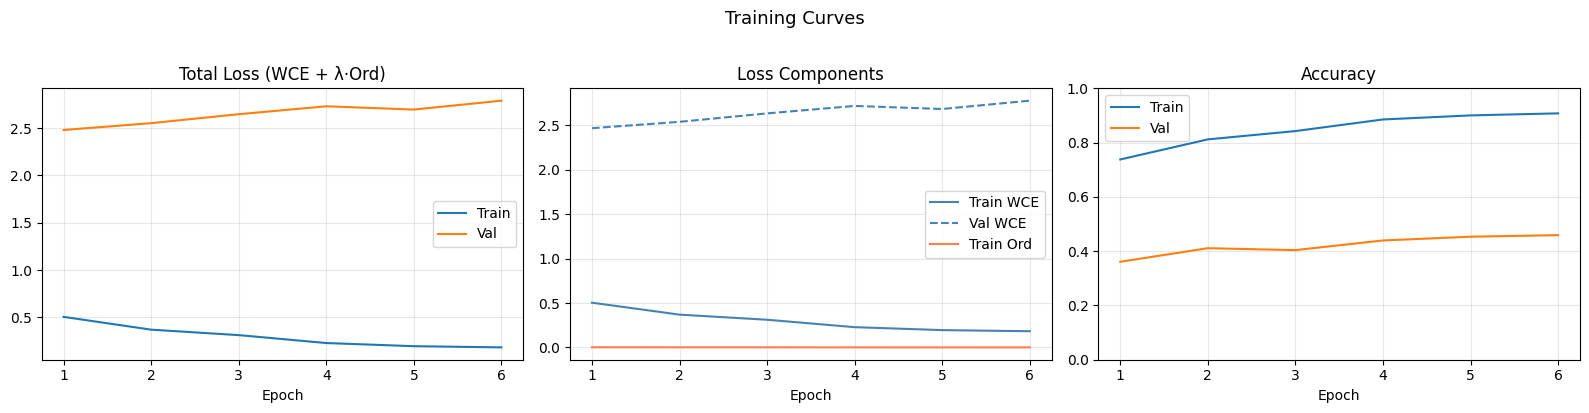

In [22]:
ep_range = range(1, len(hist['tr_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ep_range, hist['tr_loss'], label='Train')
axes[0].plot(ep_range, hist['va_loss'], label='Val')
axes[0].set_title('Total Loss (WCE + λ·Ord)')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, hist['tr_wce'], label='Train WCE', color='steelblue')
axes[1].plot(ep_range, hist['va_wce'], label='Val WCE',   color='steelblue', linestyle='--')
axes[1].plot(ep_range, hist['tr_ord'], label='Train Ord', color='coral')
axes[1].set_title('Loss Components')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep_range, hist['tr_acc'], label='Train')
axes[2].plot(ep_range, hist['va_acc'], label='Val')
axes[2].set_title('Accuracy')
axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0, 1)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Training Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print('Evaluating on test set...')
te = eval_epoch(model, test_loader, criterion)
print(f'\nTest Accuracy : {te["acc"]:.4f}')
print(f'Test WCE Loss : {te["wce"]:.4f}')
print('\n' + '='*60)
print(classification_report(
    te['labels'], te['preds'],
    labels=list(range(NUM_CLASSES)),
    
    target_names=STAGE_ORDER,
    zero_division=0,
))

Evaluating on test set...

Test Accuracy : 0.3848
Test WCE Loss : 2.2351

              precision    recall  f1-score   support

        tPB2       0.00      0.00      0.00         0
        tPNa       0.94      0.45      0.61       450
        tPNf       0.22      0.78      0.34        96
          t2       0.70      0.47      0.57       413
          t3       0.18      0.26      0.21        87
          t4       0.40      0.31      0.35       426
          t5       0.08      0.09      0.09       129
          t6       0.00      0.00      0.00        82
          t7       0.18      0.36      0.24       176
          t8       0.38      0.21      0.27       429
         t9+       0.52      0.42      0.47       615
          tM       0.32      0.54      0.40       274
         tSB       0.23      0.30      0.26       210
          tB       0.23      0.28      0.25        80
         tEB       0.57      0.62      0.60       200
         tHB       0.00      0.00      0.00         0

    ac

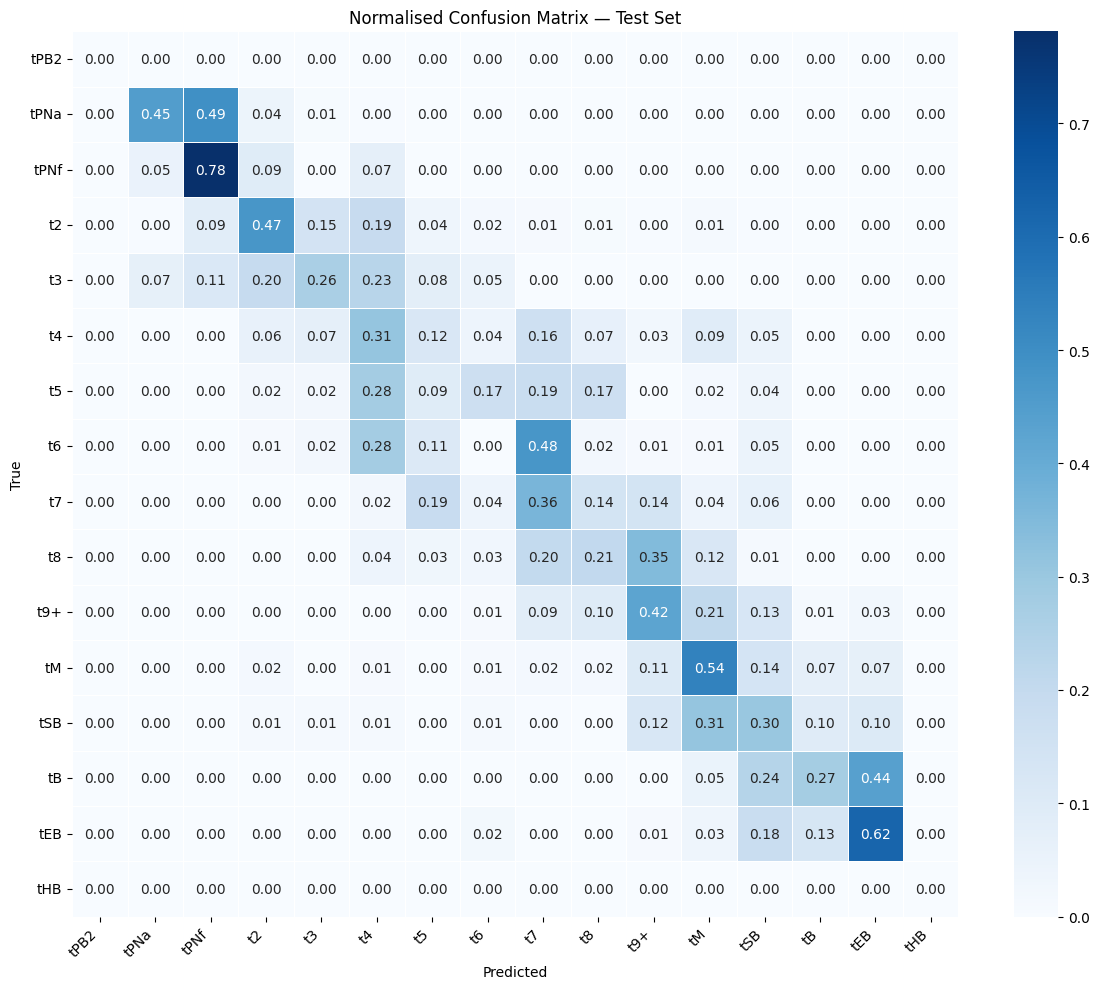

In [24]:
cm      = confusion_matrix(te['labels'], te['preds'], labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=STAGE_ORDER, yticklabels=STAGE_ORDER,
            linewidths=0.4, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Normalised Confusion Matrix — Test Set')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

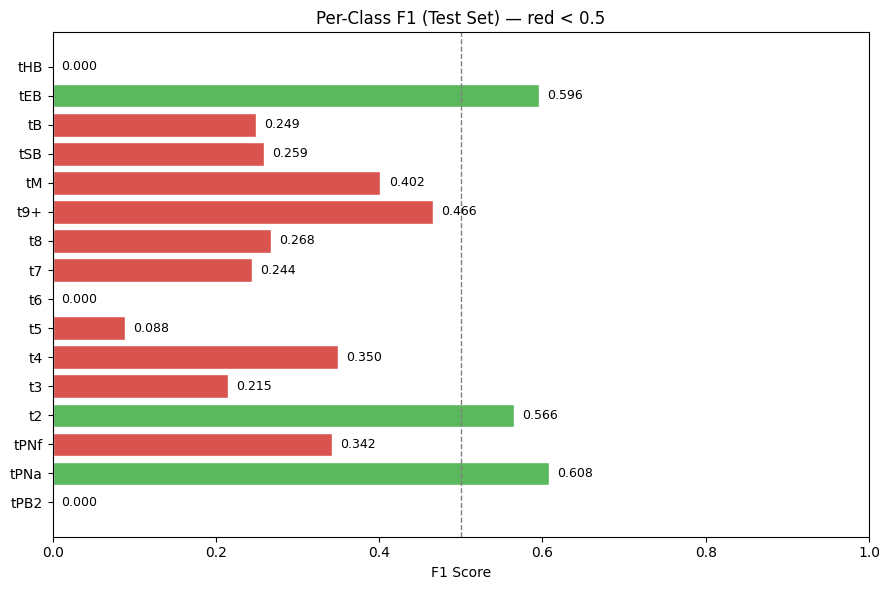

In [25]:
f1s    = f1_score(te['labels'], te['preds'], average=None,
                  labels=list(range(NUM_CLASSES)), zero_division=0)
colors = ['#d9534f' if v < 0.5 else '#5cb85c' for v in f1s]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(STAGE_ORDER, f1s, color=colors, edgecolor='white')
ax.axvline(0.5, color='grey', linestyle='--', lw=1)
ax.set_xlim(0, 1); ax.set_xlabel('F1 Score')
ax.set_title('Per-Class F1 (Test Set) — red < 0.5')
for i, v in enumerate(f1s):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
import json
results = {
    'test_accuracy': te['acc'],
    'test_wce':      te['wce'],
    'per_class_f1':  f1s.tolist(),
    'history':       hist,
}
with open('/kaggle/working/results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('='*50)
print('        FINAL TEST RESULTS')
print('='*50)
print(f'  Accuracy : {te["acc"]*100:.2f}%')
print(f'  Macro F1 : {f1s.mean():.4f}')
print(f'  WCE Loss : {te["wce"]:.4f}')
print('='*50)
print('Saved: checkpoints/best_model.pth | training_curves.png | confusion_matrix.png | per_class_f1.png | results.json')

        FINAL TEST RESULTS
  Accuracy : 38.48%
  Macro F1 : 0.2907
  WCE Loss : 2.2351
Saved: checkpoints/best_model.pth | training_curves.png | confusion_matrix.png | per_class_f1.png | results.json
